[solve] start: cycle_00_initial (Nv=2, Ne=1)
[solve] done : cycle_00_initial


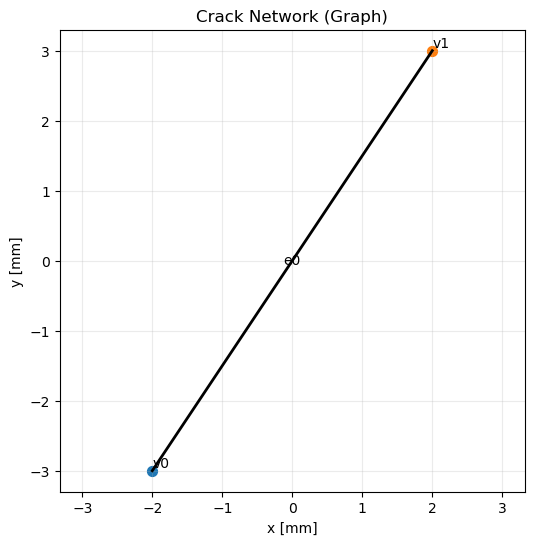

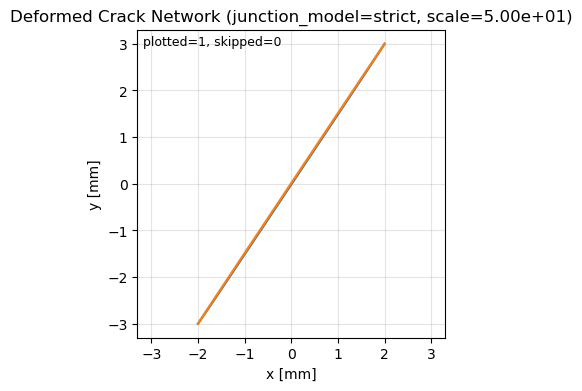

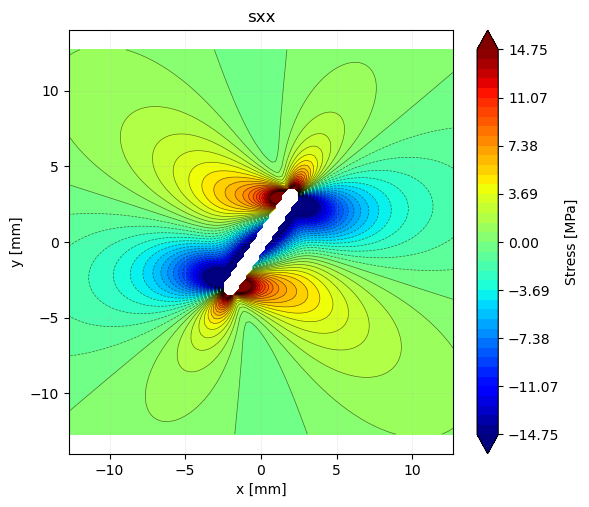

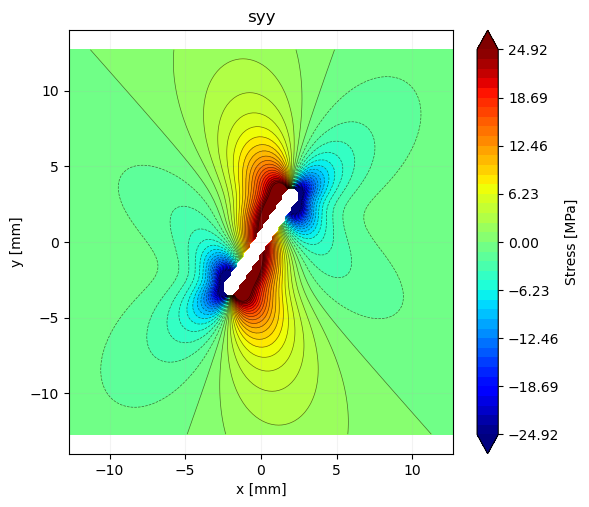

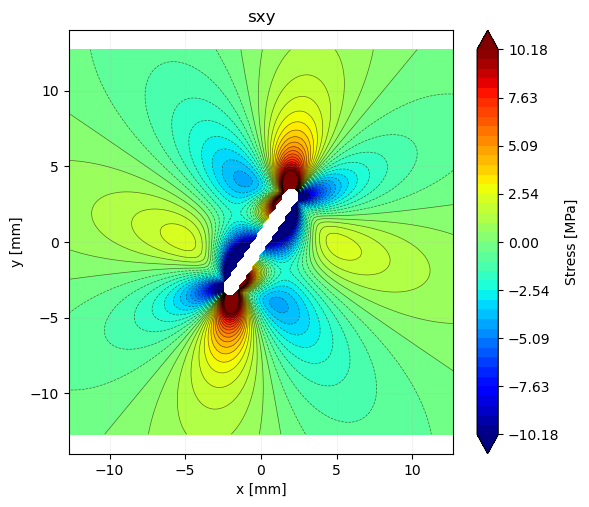

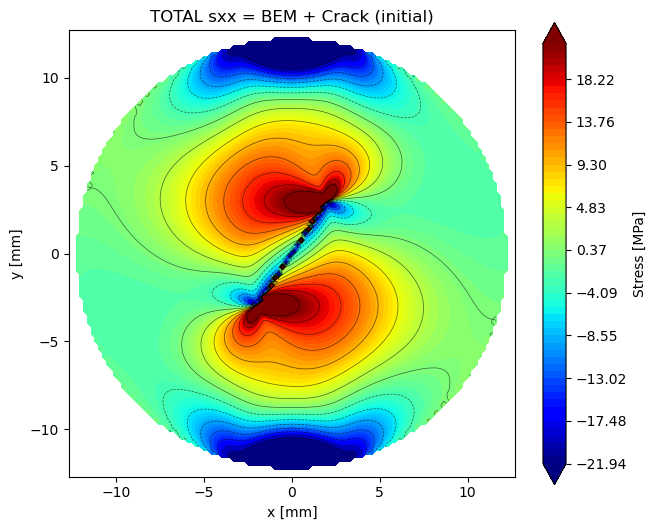

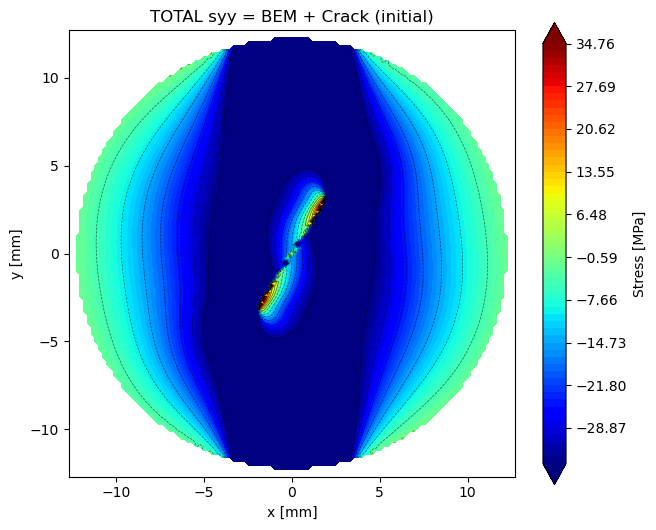

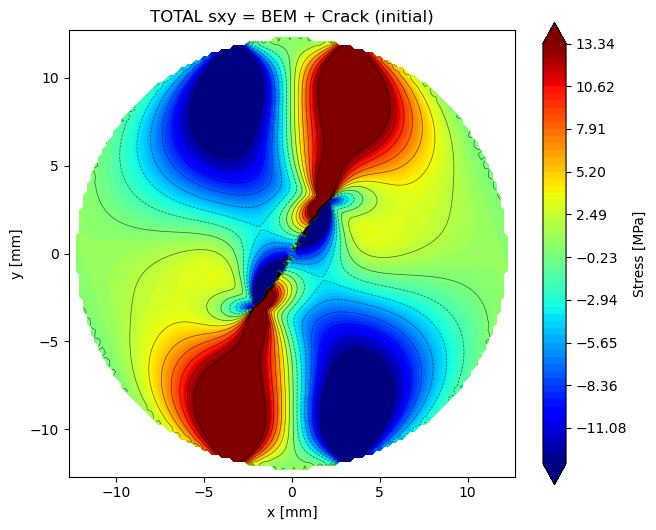

[solve] start: cycle_01_pre_simplify (Nv=18, Ne=17)
[solve] done : cycle_01_pre_simplify


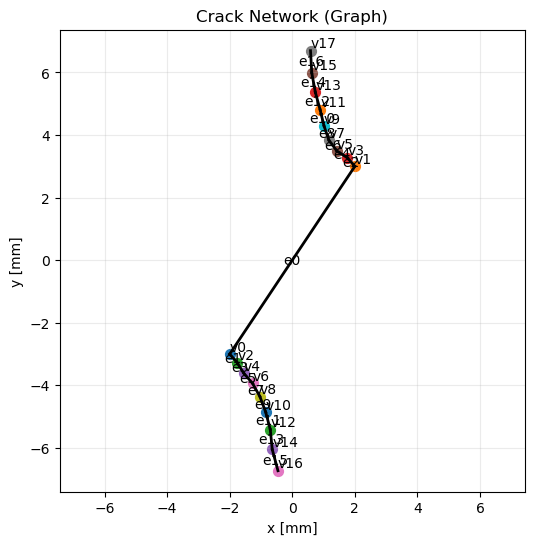

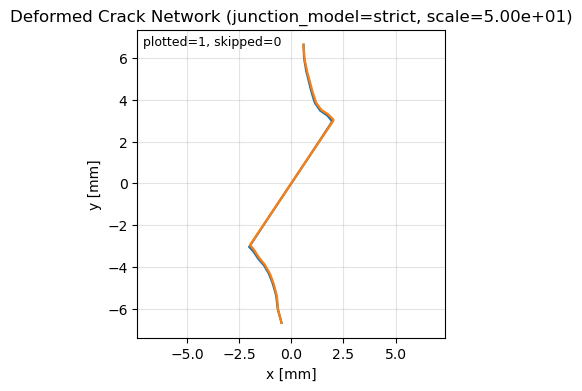

✓ Loaded network: 18 vertices, 17 edges
[solve] start: cycle_01_post_simplify (Nv=17, Ne=16)
[solve] done : cycle_01_post_simplify


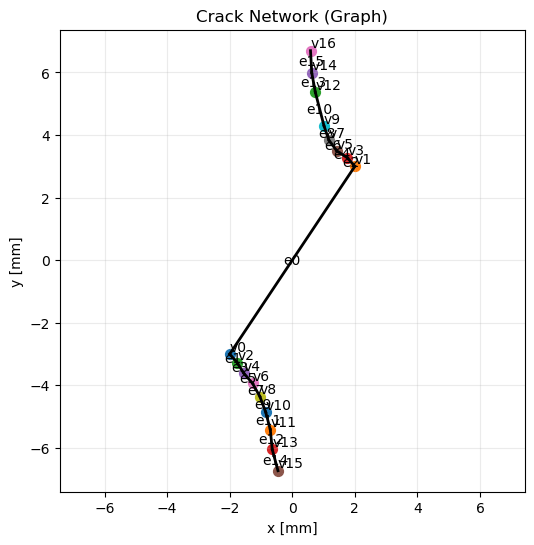

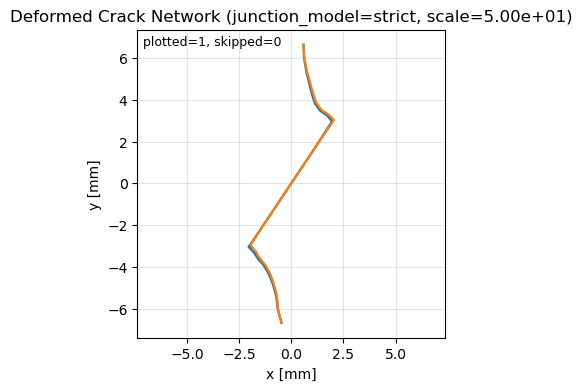

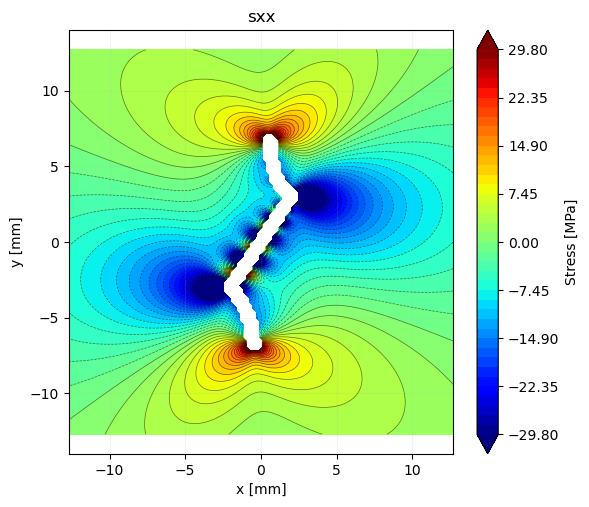

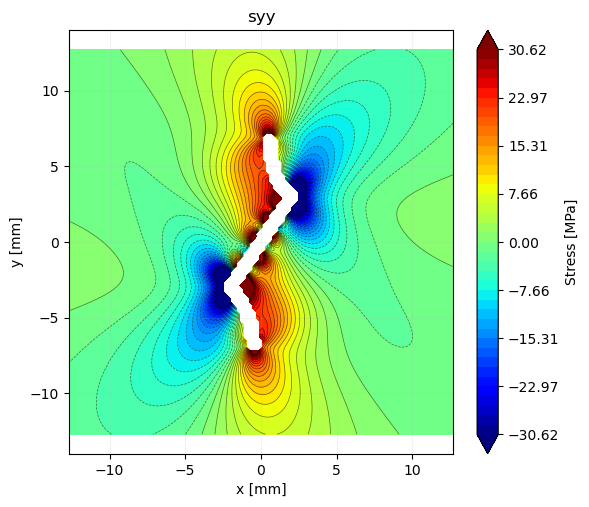

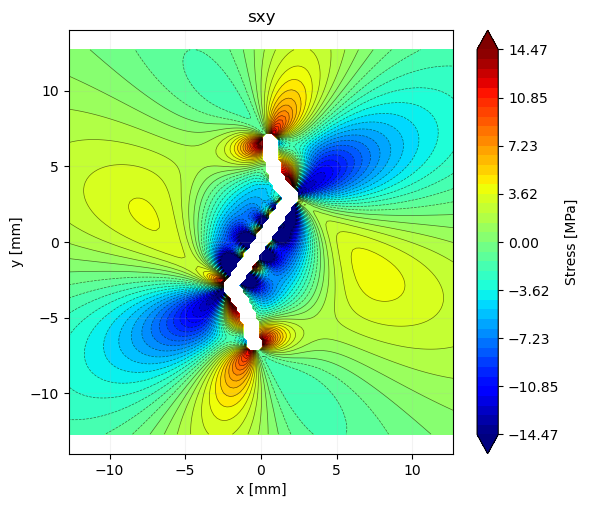

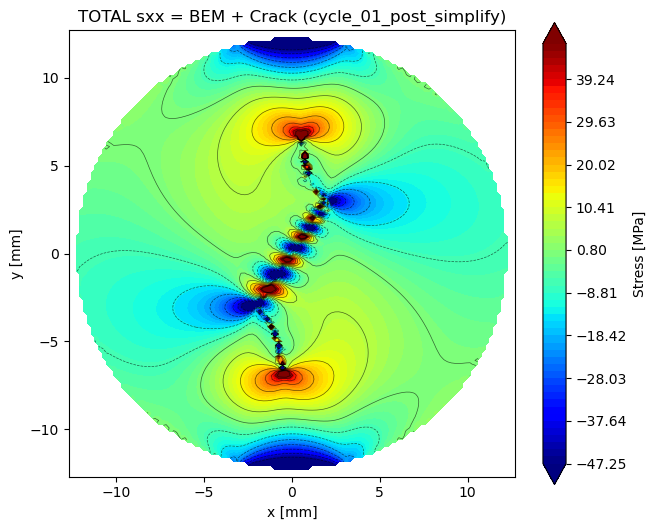

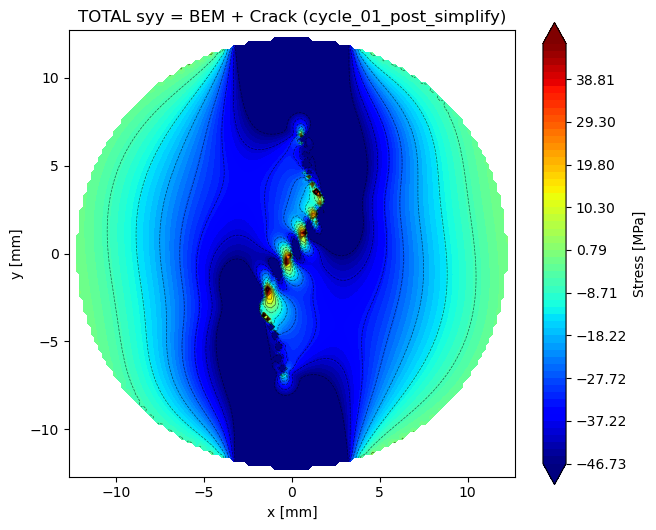

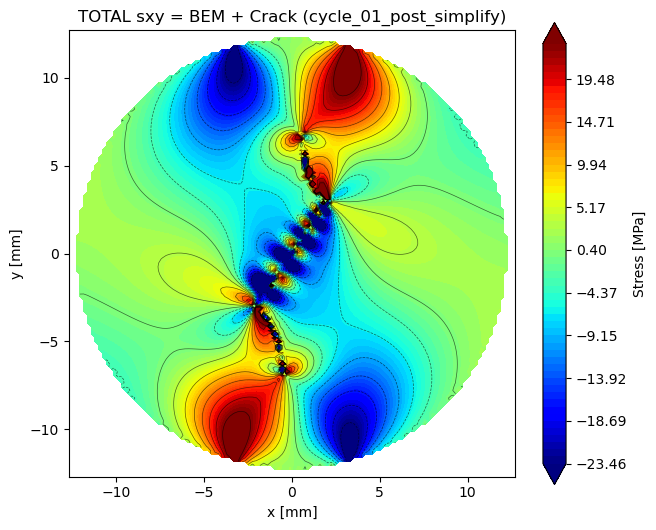

[solve] start: cycle_02_pre_simplify (Nv=19, Ne=18)
[solve] done : cycle_02_pre_simplify


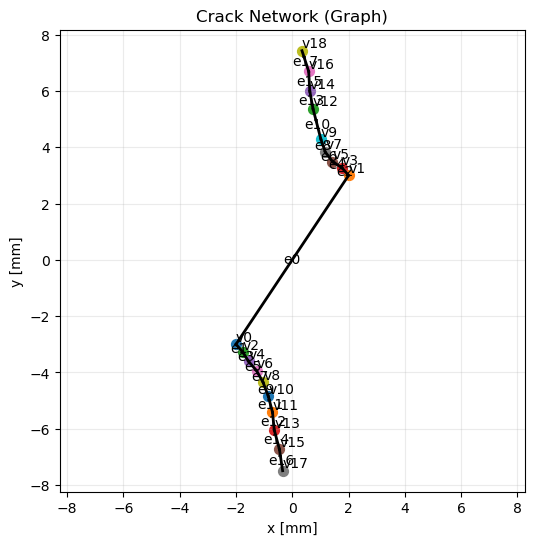

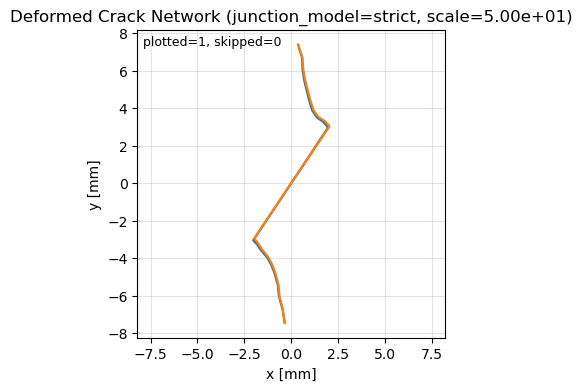

✓ Loaded network: 19 vertices, 18 edges
[solve] start: cycle_02_post_simplify (Nv=19, Ne=18)
[solve] done : cycle_02_post_simplify


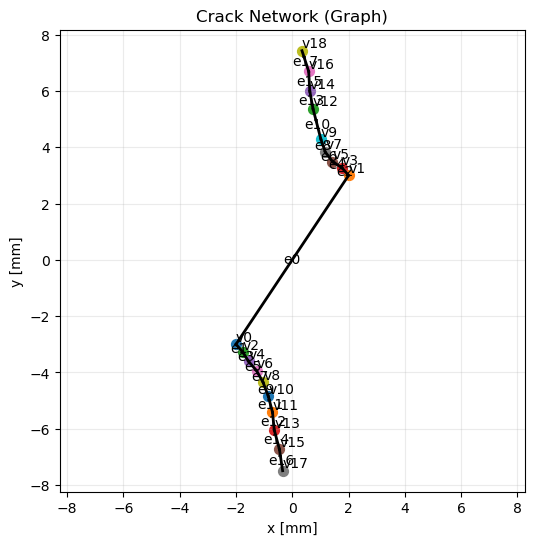

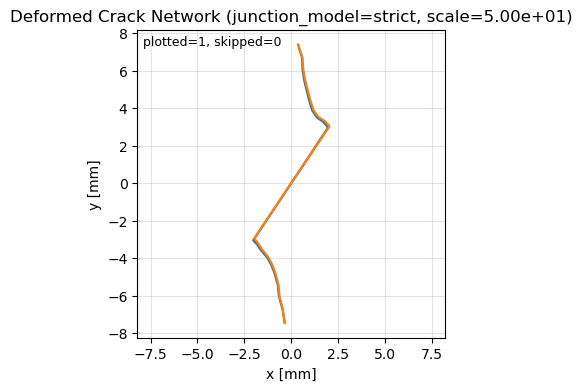

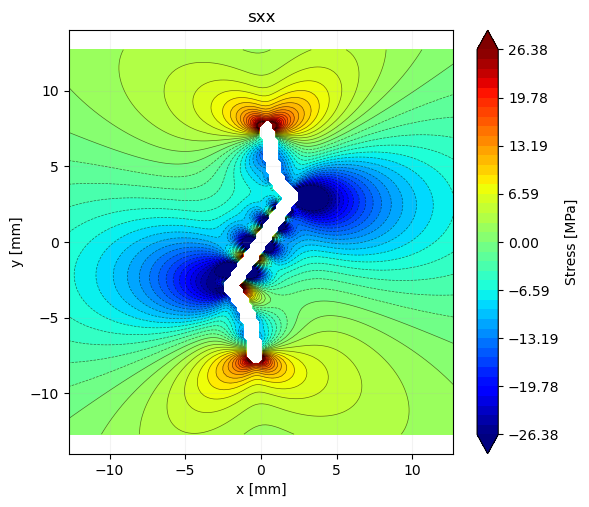

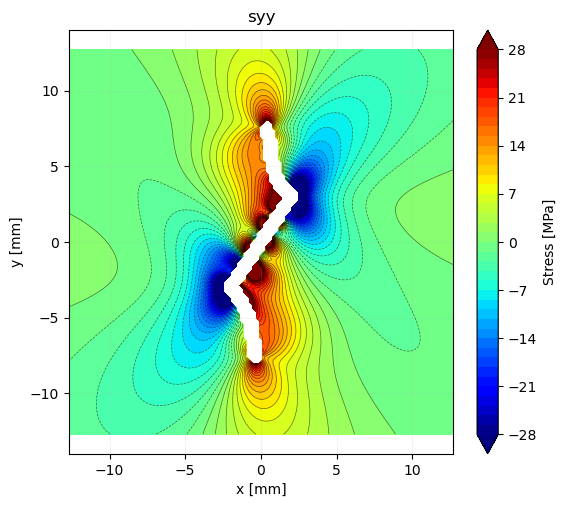

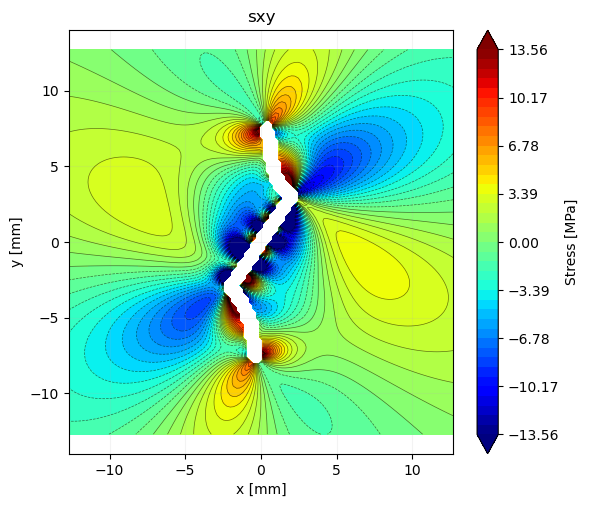

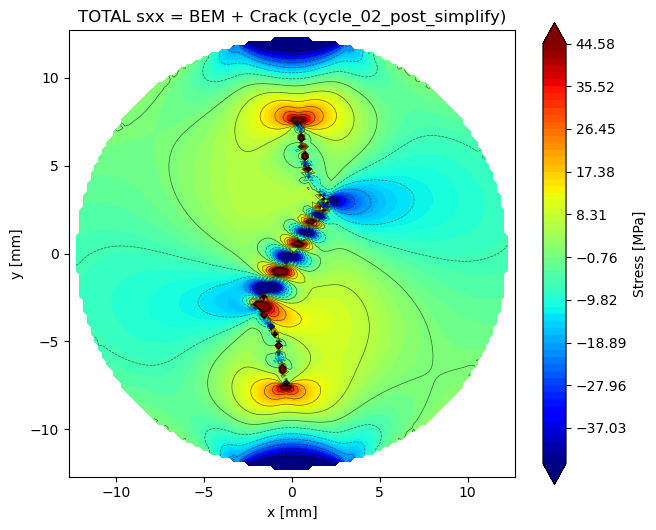

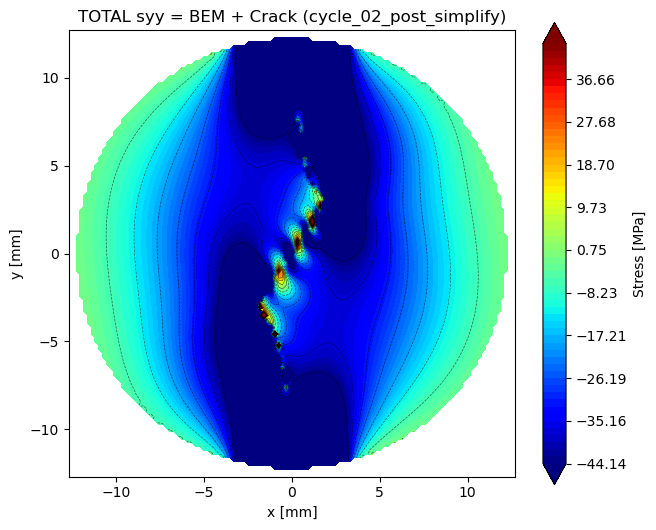

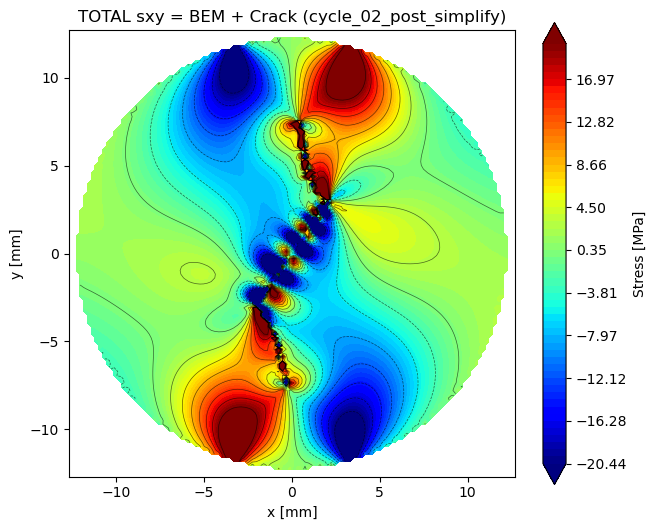

[solve] start: cycle_03_pre_simplify (Nv=21, Ne=20)
[solve] done : cycle_03_pre_simplify


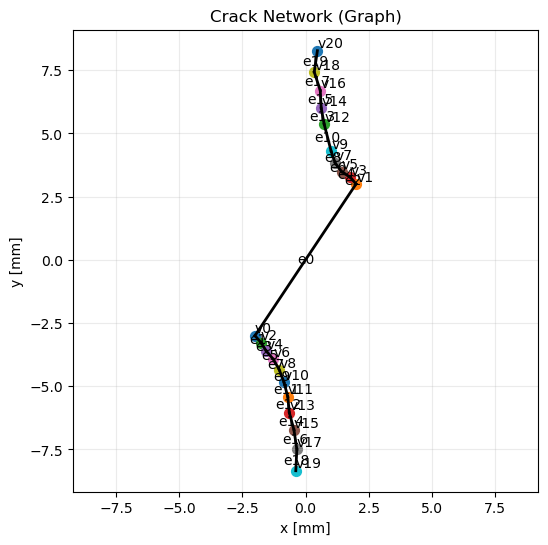

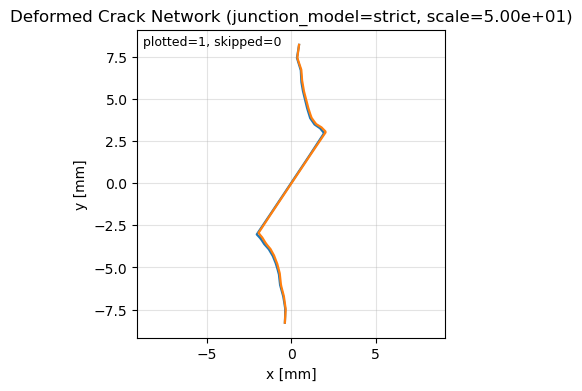

✓ Loaded network: 21 vertices, 20 edges
[solve] start: cycle_03_post_simplify (Nv=21, Ne=20)
[solve] done : cycle_03_post_simplify


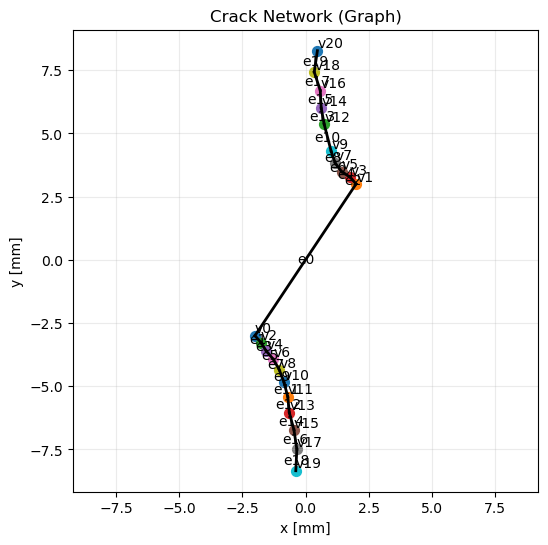

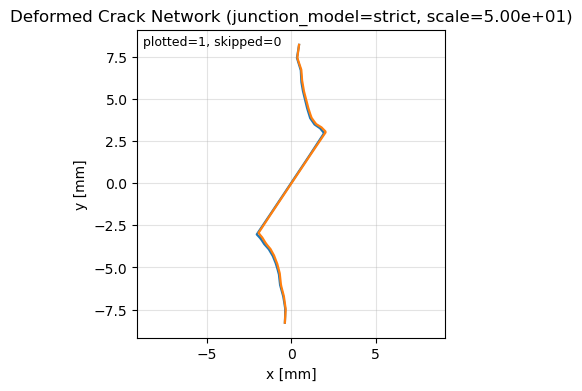

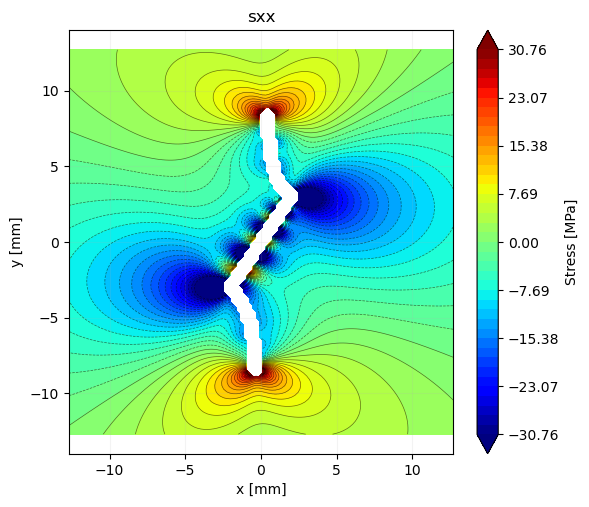

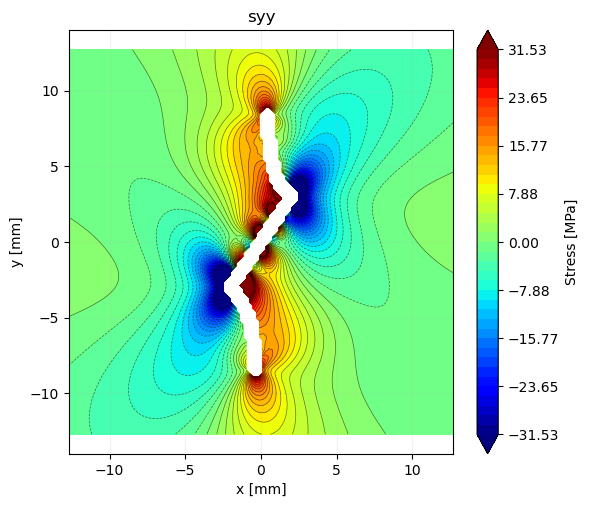

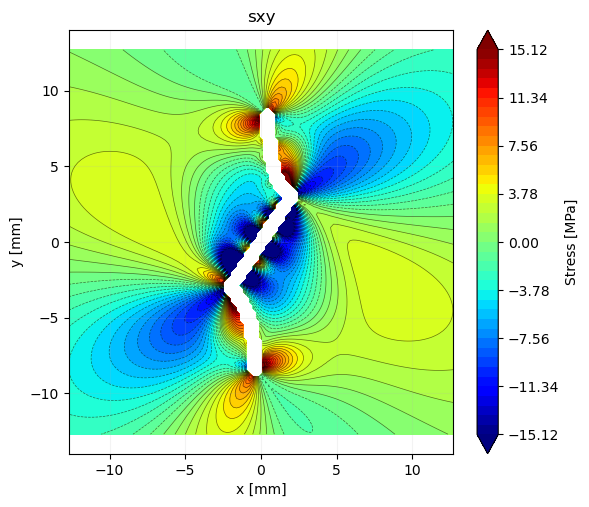

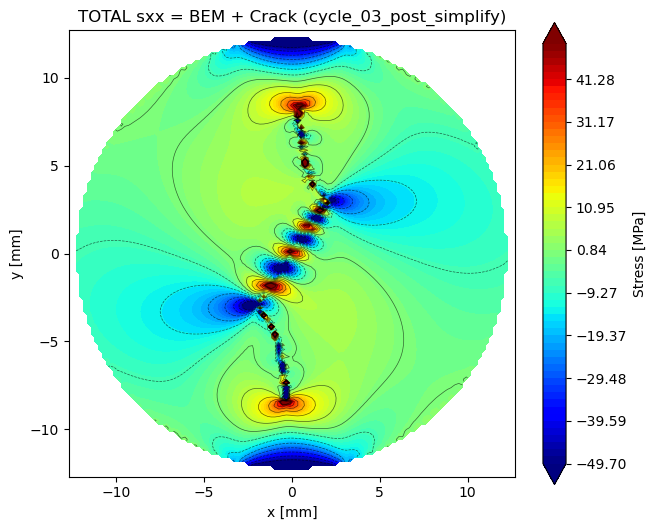

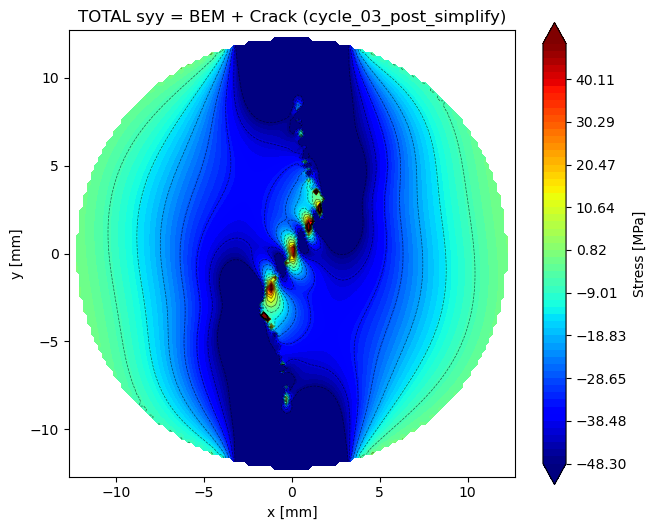

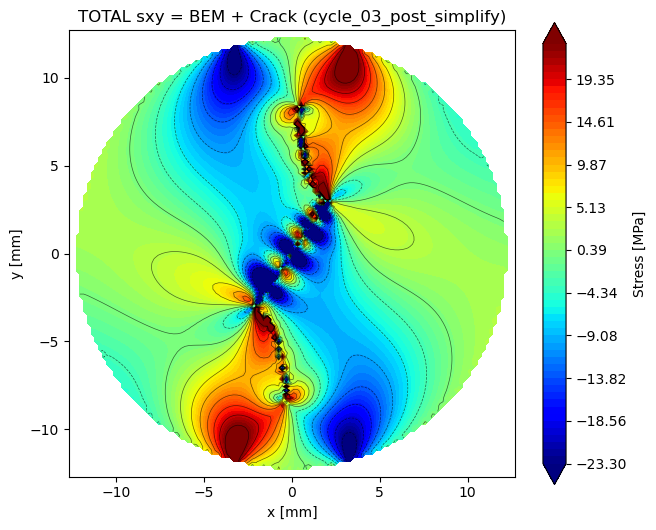

[solve] start: cycle_04_pre_simplify (Nv=23, Ne=22)
[solve] done : cycle_04_pre_simplify


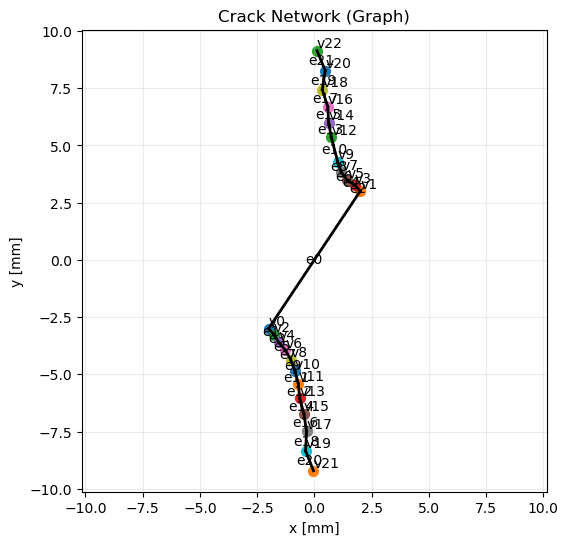

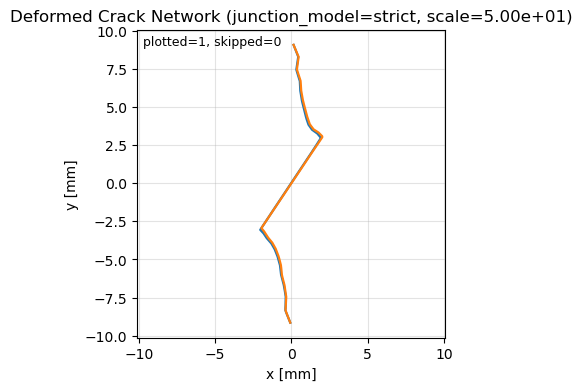

✓ Loaded network: 23 vertices, 22 edges
[solve] start: cycle_04_post_simplify (Nv=23, Ne=22)
[solve] done : cycle_04_post_simplify


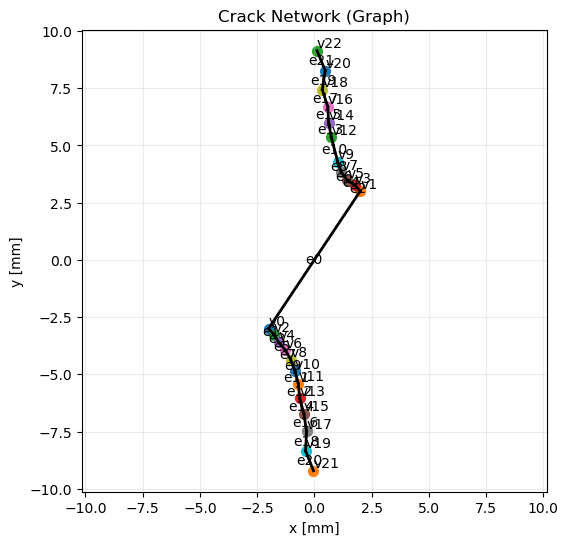

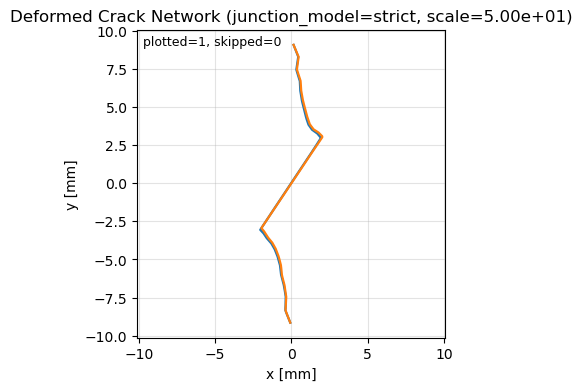

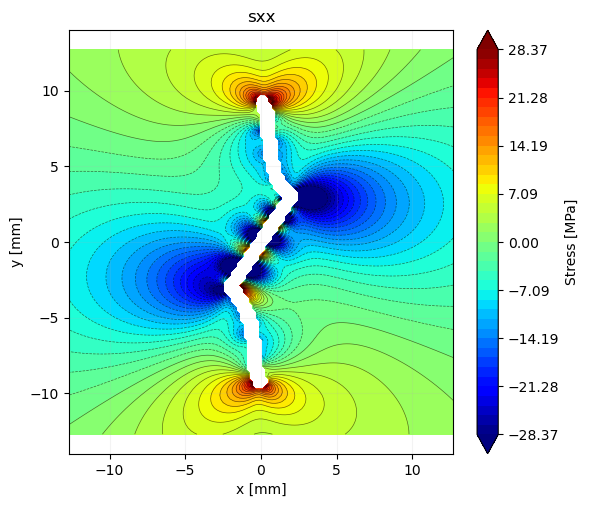

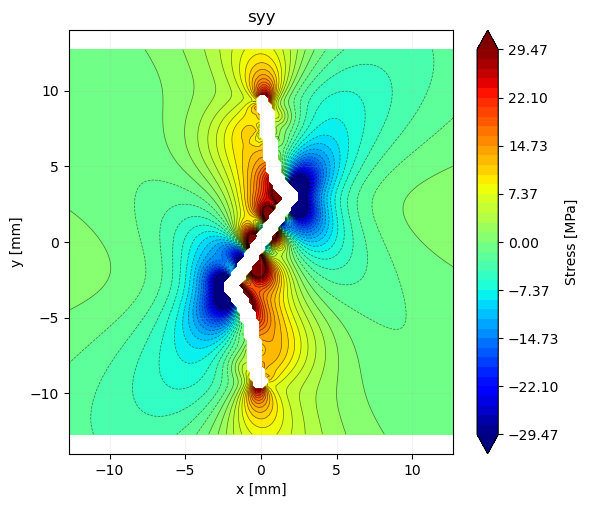

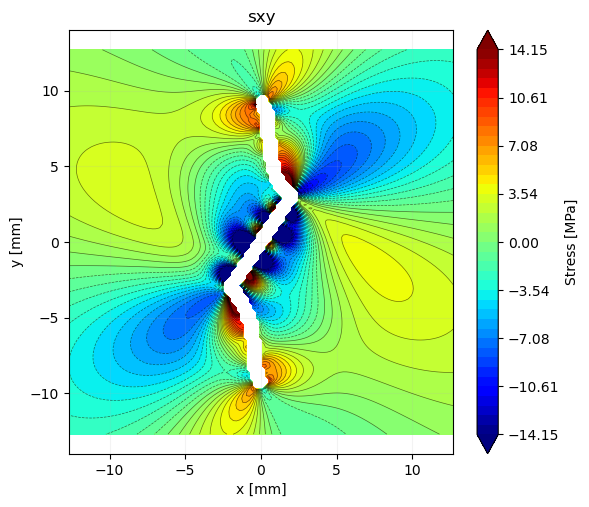

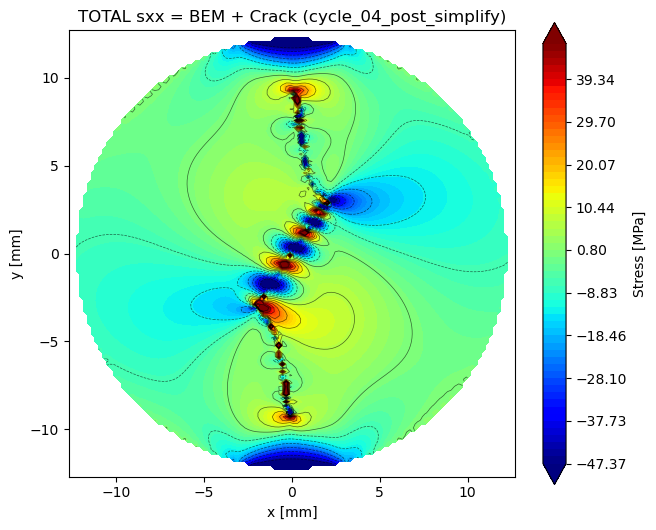

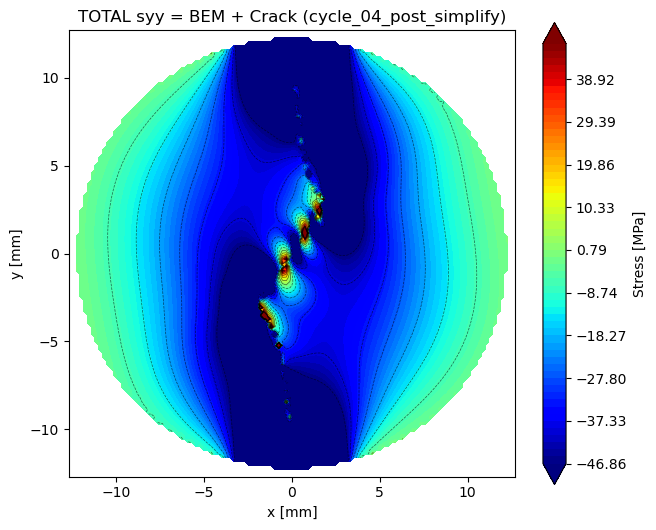

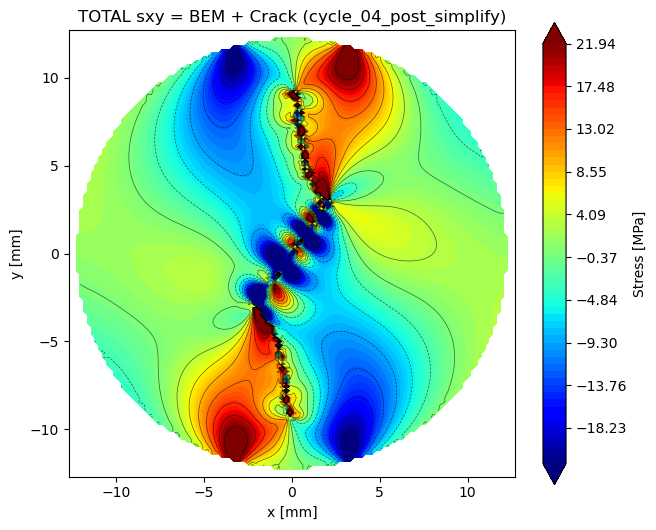

[solve] start: cycle_05_pre_simplify (Nv=25, Ne=24)
[solve] done : cycle_05_pre_simplify


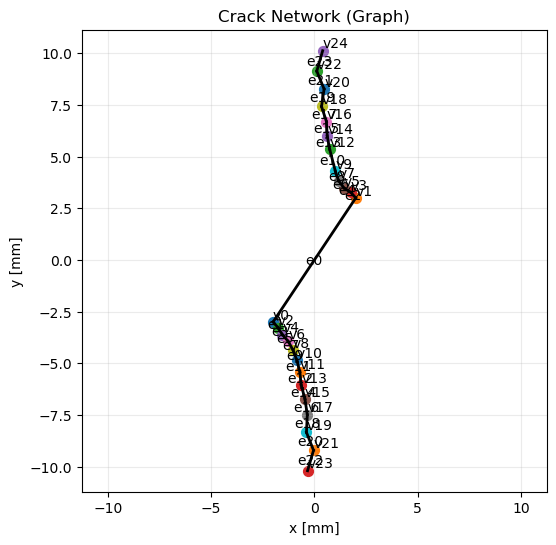

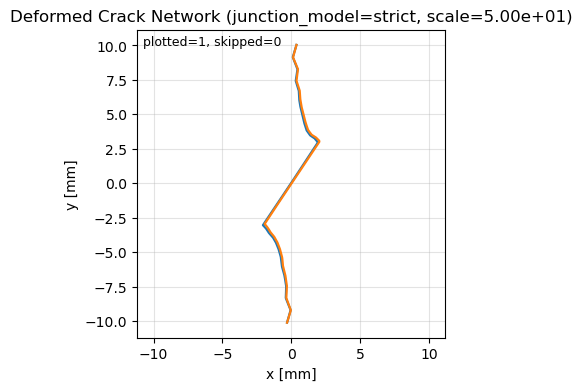

✓ Loaded network: 25 vertices, 24 edges
[solve] start: cycle_05_post_simplify (Nv=25, Ne=24)
[solve] done : cycle_05_post_simplify


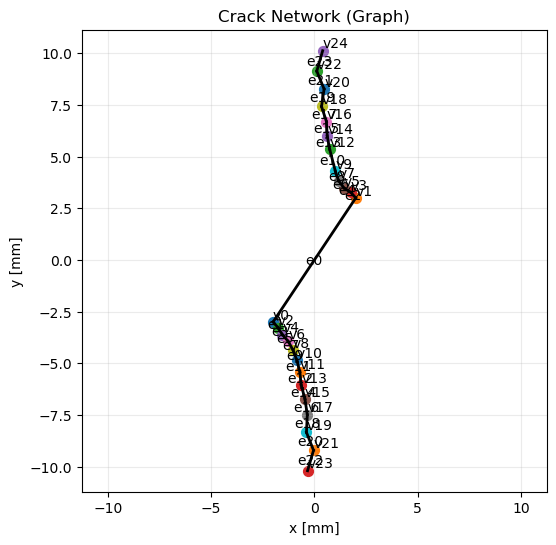

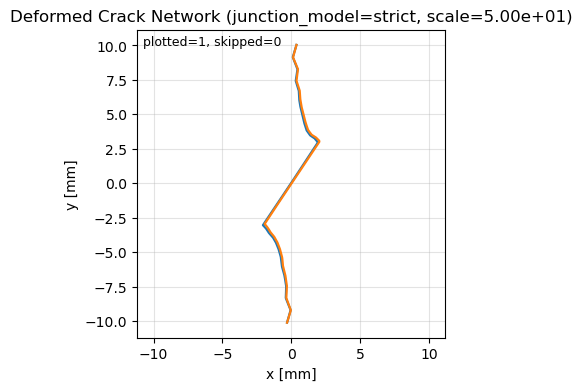

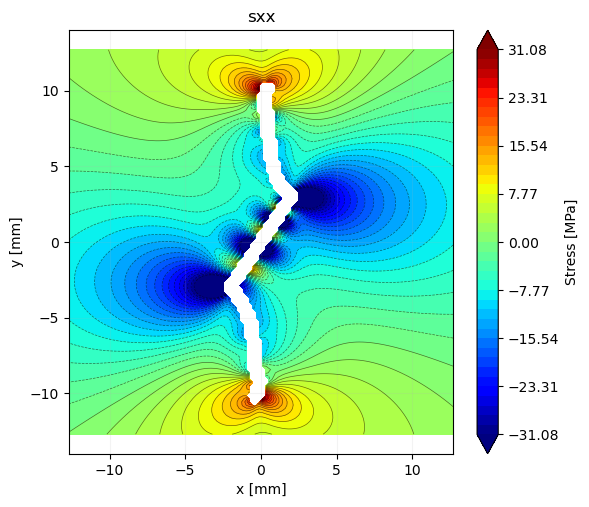

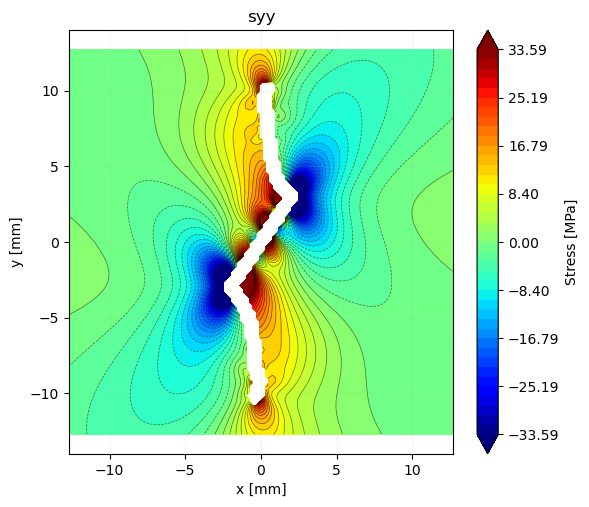

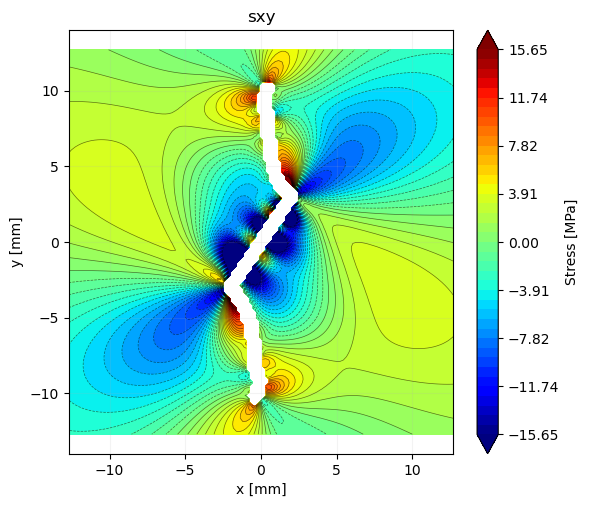

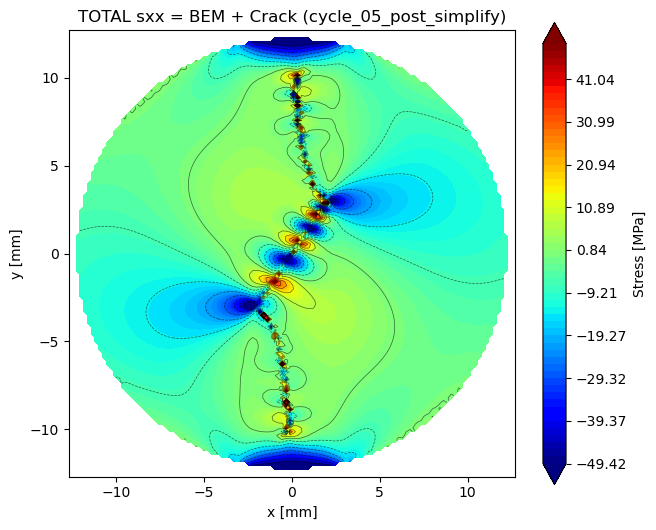

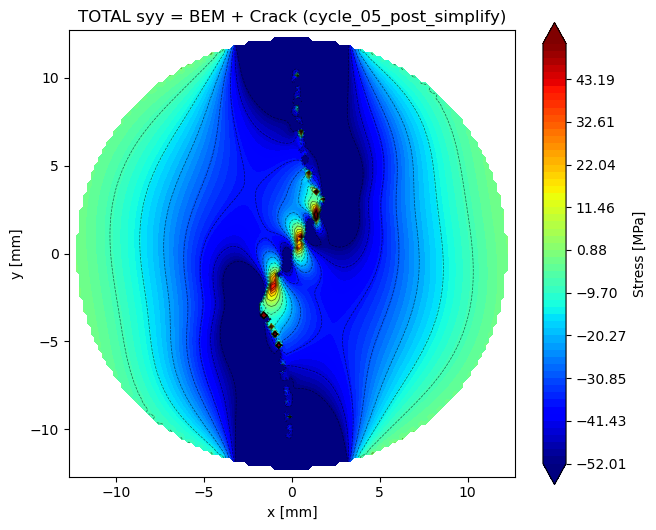

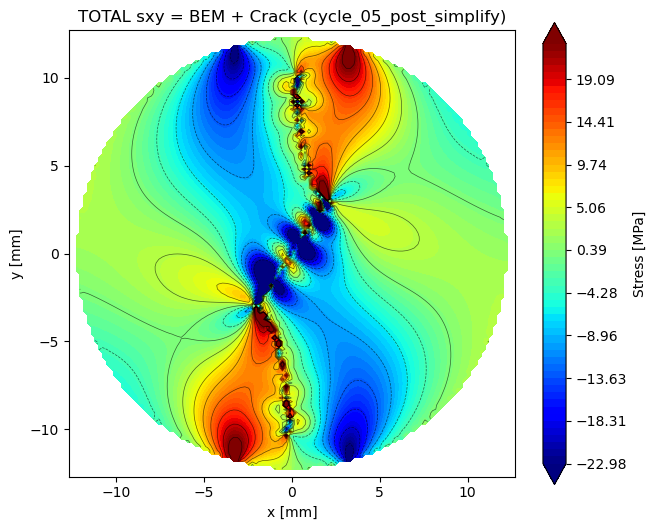

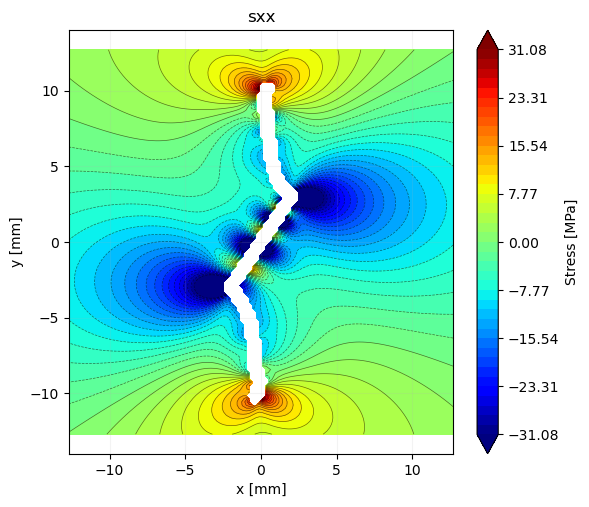

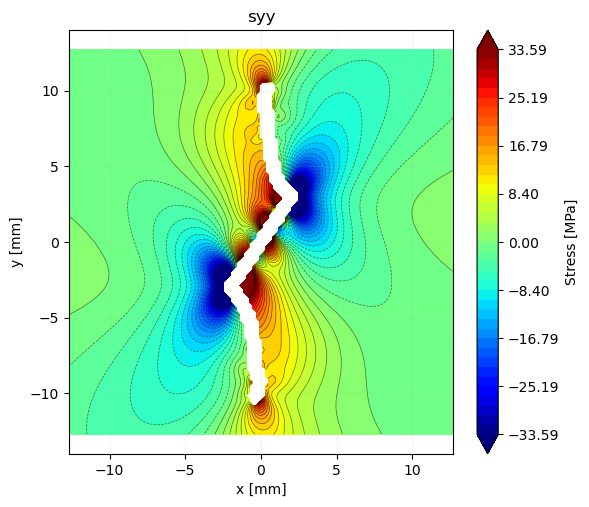

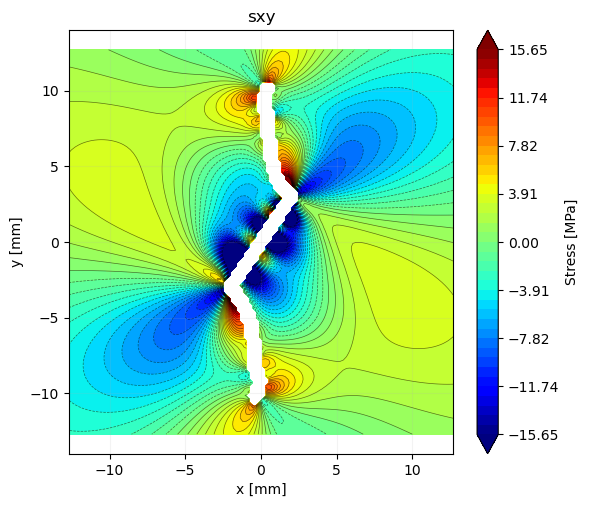

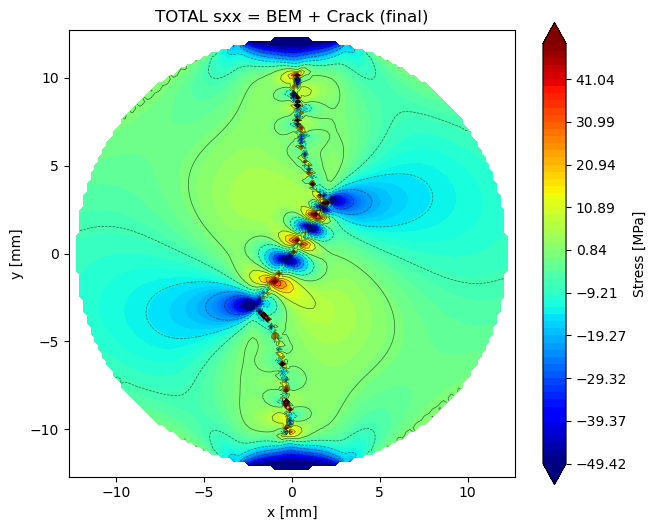

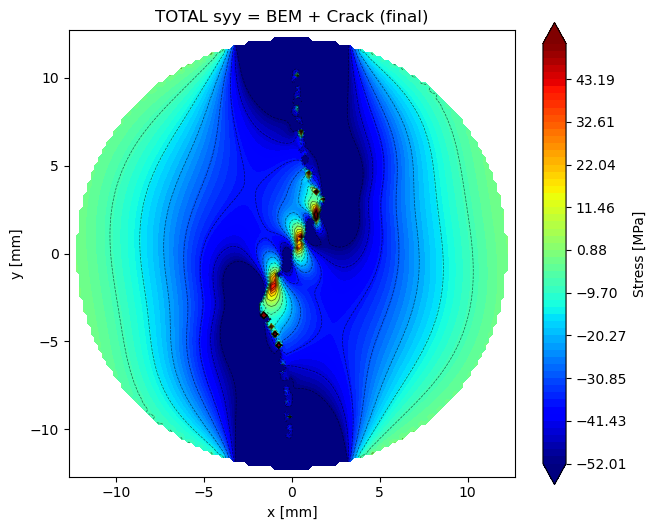

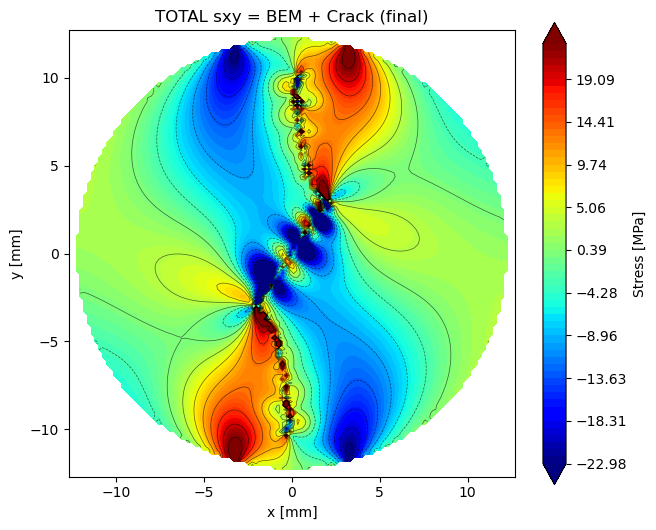

In [2]:
from pathlib import Path
import os, sys
import numpy as np

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fracture_utils.Ubem.brazilian_disk_bem import (BrazilianDiskParams, ensure_bem_field)
from fracture_utils.Ubem.disk_network_propagation import (CrackGrowthParams, run_network_growth_uncoupled)
from fracture_utils.Ubem.disk_crack_plotting import PlotParams, make_standard_plot_hook

bem_dir   = repo_root / "output" / "BEM_Brazilian_disk"
# crack_dir = repo_root / "output" / "KinkedCrackPropagation"
# combined_dir = bem_dir / "combined_uncoupled"

# -----------------------
# Network (YOU control)
# -----------------------
mm = 1e-3
vertices = np.array([
    [0, -2.0*mm, -3.0*mm],
    [1,  2.0*mm,  3.0*mm],
], float)

connectivity = np.array([[0, 1]], int)

# -----------------------
# (1) BEM (fast reuse option)
# -----------------------
SKIP_BEM_SOLVE = True   # <-- set False to recompute
disk = BrazilianDiskParams(R=25.4e-3/2, P_total=3.8e3, E=231.52e9, nu=0.3, n_elem=60, n_grid=120)

ensure_bem_field(
    disk,
    bem_dir,
    recompute=(not SKIP_BEM_SOLVE),
    show=True,              # only used if recompute=True
    save_contours=True,     # only used if recompute=True
)

# -----------------------
# (2) Propagation + TOTAL-only plotting
# -----------------------

plot_params = PlotParams(
    cmap="jet",
    match_limits_to_crack=True,   
    robust=True,
    robust_pct=97.0,
    symmetric=True,
    vmax_factor=2.0,
    n_levels=60,
    n_line_levels=15,
    dpi=300,
)

hook = make_standard_plot_hook(
    bem_dir=bem_dir,
    combined_out_dir=bem_dir,
    plot_params=plot_params,
    show_initial=True,
    show_cycles=True,
    show_final=True,
)


grow = CrackGrowthParams(max_cycles=5, L_limit_mm=20.0, vertex_high=18)

res_final = run_network_growth_uncoupled(
    bem_dir=bem_dir,
    out_dir=bem_dir,
    vertices=vertices,
    connectivity=connectivity,
    params=grow,
    plot_hook=hook,
)
